<a href="https://colab.research.google.com/github/tphlabs/data/blob/main/Lab3_CO/2026.03/Lab3_Oscillator_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab3 1DoF and 2DoF Oscillators experiments

Evgeny Kolonsky, Mar 2026

In [1]:
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt
from urllib.request import urlopen
from scipy.signal import find_peaks, peak_prominences
from scipy.stats import linregress
from scipy.optimize import curve_fit


# One degree of freedom

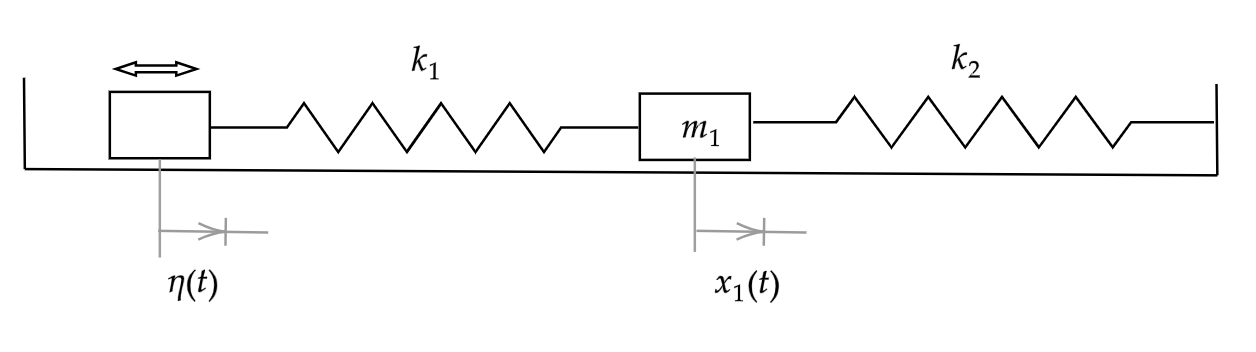

Motion equation
$$
\ddot x + \frac{1}{\tau}\dot x + \omega_0^2 x = A \cos\omega t
\tag{1.1}
$$
where $ \omega_0 = \sqrt{\frac{k_1 + k_2}{m}}$.

Solution is the sum of decaying oscillations with frequency $\omega_1$ and  and stationary state oscialtions with frequency $\omega$:
$$
x(t) = A_0 e^{-\frac{t}{2\tau}} \cos(\omega_1 t + \phi) + B\cos(\omega t - \psi)
\tag{1.2}
$$

Oscillations freqeuency $\omega_1$ is slightly less than natural frequency $\omega_0$:
$$
\omega_1  = \sqrt{\omega_0^2 - \frac{1}{4\tau^2}} = \omega_0 \sqrt{1 - \frac{1}{4 Q^2}}
\tag{1.3},
$$
where quality factor $Q = \omega_0 \tau$.

At stationary state amplitude realtive response $\tilde B = B/A$ and phase $\psi$ are depending on relative force frequency $\tilde\omega = \omega / \omega_0$:
$$
\tilde B = \frac{k_1}{k_1+k_2} \frac{1}{\sqrt{\left(1 - \tilde\omega^2\right)^2 + \tilde\omega^2 / Q^2}}
\tag{1.4}
$$

$$
\psi =\arctan \left( \frac{\tilde\omega / Q}{1 - \tilde\omega^2}\right)
\tag{1.5}
$$

Noting that  $a = 1-\tilde\omega^2$ and $b = \tilde\omega/Q$ are sides of right triangle with third side $c = \sqrt{a^2 + b^2}$, we can rewrite
$$
\cos\psi = \frac{a}{c} = \frac{1-\tilde\omega^2}{\sqrt{(1-\tilde\omega^2)^2 + (\tilde\omega/Q)^2}}
\tag{1.6}
$$

Cosine of phase between two harmonic oscillations $x_1 = A_1\cos(\omega t)$ and $x_2 = A_2 \cos(\omega t + \psi)$ can be found with scalar multiplication
$$
\cos\psi = \frac{x_1 \cdot x_2} {|x_1| \, |x_2|}
\tag{1.7}.
$$


In [2]:
# place here your repository raw data path
PATH = 'https://raw.githubusercontent.com/tphlabs/data/refs/heads/main/Lab3_CO/2026.03/'
# lambda-function concatenating PATH and filename
URL = lambda name: f'{PATH}{name}'

In [3]:
#  data analysis functions

def get_signal(url, show=False):
  data = np.loadtxt(url).T
  t = data[1, :]
  # convert from counts to meters
  x = data[2:, :]
  # how many signals: Kruze may return  from 1 up to 4
  signals = x.shape[0]
  # shift mean to zero
  for i in range(signals):
    x[i] -= x[i].mean()
  if show:
    for i in range(signals):
      plt.plot(t, x[i], label=f'Cart {i+1}')
    plt.grid()
    plt.xlabel('Time, s')
    plt.ylabel('Amplitude, m')
    plt.legend()
  # returns t and signals x1, x2, ..
  answer = [t] + [x[i] for i in range(signals)]
  return tuple(answer)

def get_peaks(t, signal, show=False):
  rate = np.median(np.diff(t))
  min_period = 0.2 #s
  min_prominence = 2e-3 ## 2 mm
  peaks, _ = find_peaks(signal, prominence=min_prominence,
                        distance=min_period/rate )
  if show:
    plt.plot(signal)
    plt.grid()
    plt.plot(peaks, signal[peaks], "x")
    plt.xlabel('Points')
    plt.ylabel('Signal')
  return t[peaks], signal[peaks]

def get_frequency(t, harmonic_signal):
  tpeaks, _ = get_peaks(t, harmonic_signal)
  periods = np.diff(tpeaks)
  f0 = 2 * np.pi  / periods
  return np.mean(f0), np.std(f0)

# get cosine of phase difference
# between two harmonic signals x1(t), x2(t)
# having the same frequency
def get_cosine(x1, x2):
  x11 = x1 @ x1
  x12 = x1 @ x2
  x22 = x2 @ x2
  cosine = x12 / np.sqrt(x11 * x22)
  return cosine

def get_quality(t, harmonic_signal):
  tpeaks, peaks = get_peaks(t, harmonic_signal)
  decay = np.log(peaks / peaks[0])
  cycles = range(len(peaks))
  fit = linregress(cycles, decay)
  fit_relative_error = np.abs(2 * fit.stderr / fit.slope)
  Q = -np.pi/fit.slope
  Q_err = Q * fit_relative_error
  return Q, Q_err


## Parameters and expected natural frequency

In [4]:
# Cart mass
m, m_err  = 213.2e-3, 0.1e-3 # kg

relative_error = m_err / m

# springs masses
m_k1 = 17.4e-3
m_k2 = 17.3e-3


# elastity
k1  = 4.26 # N / m
k2 = 4.31


omega0 = np.sqrt((k1 + k2) / m)

omega0_err = omega0 * relative_error

print(f'Natural frequency expected = {omega0:.3f} +-{omega0_err:.3f} rad/s')


Natural frequency expected = 6.340 +-0.003 rad/s


## Direct measurements: free dumped oscillations

Frequency observed 6.221 ± 0.000 rad/s


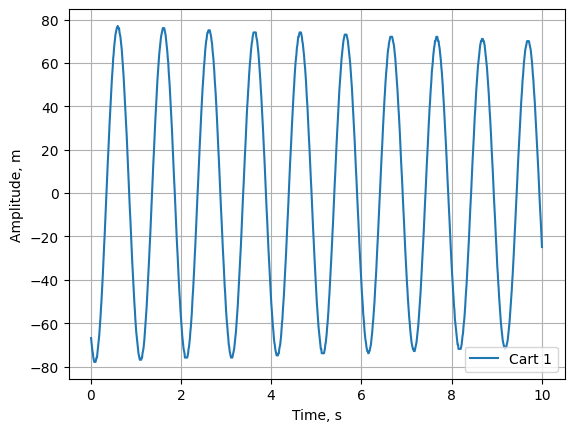

In [15]:
filename = URL('free0.txt')
t, x = get_signal(filename, show=True)
omega1, omega1_err = get_frequency(t, x)
print(f'Frequency observed {omega1:.3f} ± {omega1_err:.3f} rad/s')

Quality factor 30.9 ± 0.4
Oscialltions frequency observed 6.224 ± 0.028 rad/s
Relative error 0.005
Natural frequency observed 6.224 ± 0.028 rad/s


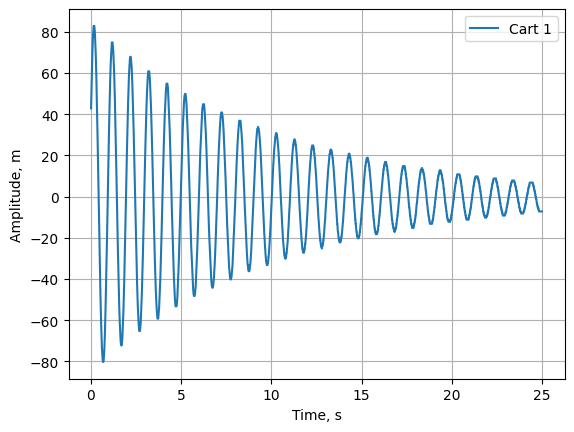

In [16]:
filename = URL('free2.txt')
t, x = get_signal(filename, show=True)
Q, Q_err = get_quality(t, x)
print(f'Quality factor {Q:.1f} ± {Q_err:.1f}')
omega1, omega1_err = get_frequency(t, x)
print(f'Oscialltions frequency observed {omega1:.3f} ± {omega1_err:.3f} rad/s')
relative_error = omega1_err / omega1
print(f'Relative error {relative_error:.3f}')
omega0 = omega1 * np.sqrt(1 + 1 / 4 / Q**2)
omega0_err = omega0 * relative_error
print(f'Natural frequency observed {omega0:.3f} ± {omega0_err:.3f} rad/s')


### Amplitude response

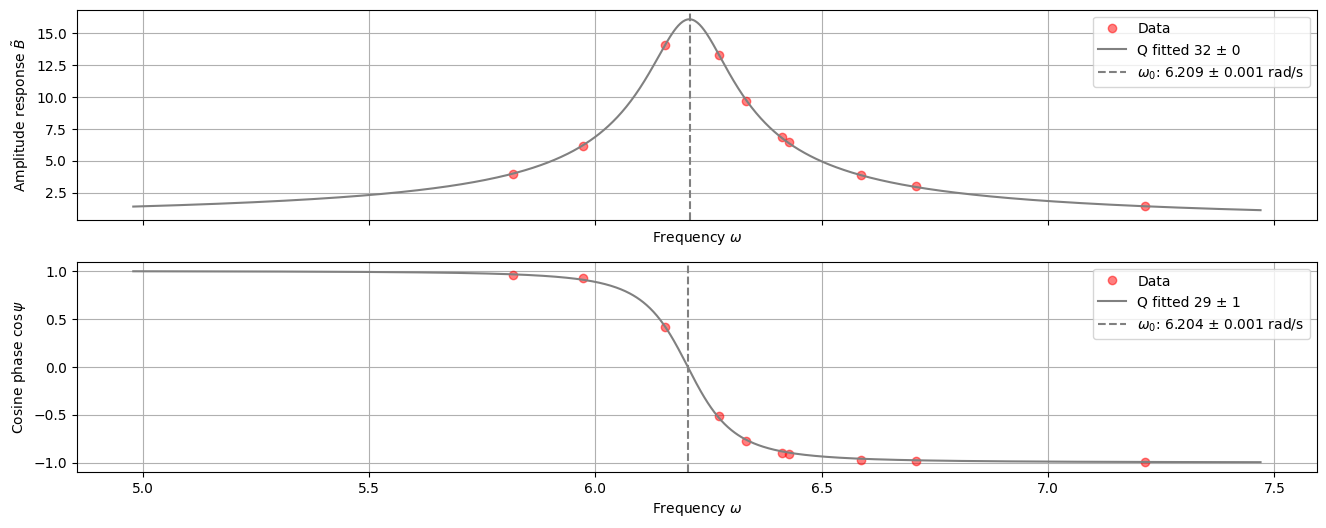

In [53]:
def amplitude_response(w, omega0, Q):
  wrel = w / omega0
  a = (1 - wrel**2)
  b = wrel / Q
  c = np.sqrt(a**2 + b**2)
  amplitude = k1 / (k1 + k2) / c
  return amplitude

def phase_response(w, omega0, Q):
  wrel = w / omega0
  a = (1 - wrel**2)
  b = wrel / Q
  c = np.sqrt(a**2 + b**2)
  cosphase = a / c
  return cosphase



fig, ax = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

names = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
fw = np.array([])
amps = np.array([])
phases = np.array([])
for name in names:
  url = URL(f'{name}.txt')
  t, xa, xb = get_signal(url, show=False)
  # get driver frequency
  fw = np.append(fw, get_frequency(t, xa)[0])
  xaa = xa @ xa
  xab = xa @ xb
  xbb = xb @ xb
  cosine = xab / np.sqrt(xaa * xbb)
  amp = np.sqrt( xbb / xaa)
  phases = np.append(phases, cosine)
  amps = np.append(amps, amp)


idx = np.argsort(fw) # sorting
ax[0].plot(fw[idx], amps[idx],  alpha=0.5, linestyle=' ', marker='o', c='red', label='Data')
ax[0].grid()
ax[0].set_xlabel(r'Frequency $\omega$')
ax[0].set_ylabel(r'Amplitude response $\tilde B$')


# Corrected curve_fit call for amplitude_response
# Use 'amps' as ydata, and provide initial guesses for omega0 and Q
parameters, pcov = curve_fit(amplitude_response, fw, amps, p0=(omega0, Q))

errs = np.sqrt(np.diag(pcov))

w0fit, Qfit = parameters
w0fit_err, Qfit_err = errs


# theory
freqs = np.linspace(0.8, 1.2, 1000) * omega0
ax[0].plot(freqs, amplitude_response(freqs, w0fit, Qfit),  color='gray', \
            label=f'Q fitted {Qfit:.0f} ± {Qfit_err:.0f}')
ax[0].axvline(w0fit, color='gray', ls='--', label=r'$\omega_0$: '+f'{w0fit:.3f} ± {w0fit_err:.3f} rad/s')
ax[0].legend();


ax[1].plot(fw[idx], phases[idx],  alpha=0.5, linestyle=' ', marker='o', c='red', label='Data')
ax[1].grid()
ax[1].set_xlabel(r'Frequency $\omega$')
ax[1].set_ylabel(r'Cosine phase $\cos\psi$')

# Corrected curve_fit call for phase_response
# Use 'phases' as ydata, and provide initial guesses for omega0 and Q
parameters, pcov = curve_fit(phase_response, fw, phases, p0=(omega0, Q))

errs = np.sqrt(np.diag(pcov))
w0fit, Qfit = parameters
w0fit_err, Qfit_err = errs

ax[1].plot(freqs, phase_response(freqs, w0fit, Qfit),  color='gray', \
          label=f'Q fitted {Qfit:.0f} ± {Qfit_err:.0f}')

ax[1].axvline(w0fit, color='gray', ls='--', label=r'$\omega_0$: '+f'{w0fit:.3f} ± {w0fit_err:.3f} rad/s')

ax[1].legend();

# Two degrees of freedom

Amplitude response as a function of driving displacemet

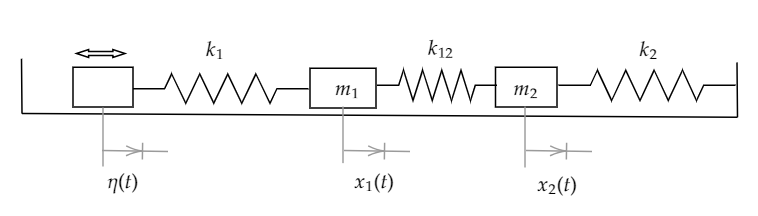



$$
\begin{matrix}
  m_1 \ddot x_1  =& -k_1(x_1 - \eta) + k_{12}(x_2 - x_1) - b_1 \dot x_1\\
  m_2 \ddot x_2  =& -k_{12}(x_2 - x_1) + k_2 x_2 - b_2 \dot x_2
\end{matrix}
$$

## Expected natural frequencies and response

Masses matrix
$$
M =  \begin{bmatrix} m_1 & 0 \\ 0 & m_2 \end{bmatrix} ,
$$
Elastic coefficients matrix
$$
K = \begin{bmatrix} k_1 +k_{12} & -k_{12} \\ -k_{12} & k_{12} +k_2 \end{bmatrix},
$$
Equation for free oscillations without friction
$$
M \ddot X(t) + K X(t) = 0
$$

Let $I$ - diagonal identity matrix. Then eigenvector $\lambda$  is found from equation
$$
\det |M^{-1} K - \lambda I| =
\begin{vmatrix}
        \frac{k_1 +k_{12}}{m_1} - \lambda & -\frac{k_{12}}{m_1} \\
        -\frac{k_{12}}{m_2} & \frac{k_{12} +k_2}{m_2} - \lambda
        \end{vmatrix}
        = 0
$$


In [8]:
m1 = 212e-3
m2 = 212e-3
k1 = 4.5
k2 = 4.5
k12 = 20
M = np.array([[m1, 0],
              [0, m2]])
K = np.array([[k1 + k12, -k12],
              [-k12, k12 + k2]])


eigenvalues, E = LA.eig(LA.inv(M) @ K)
omega_theor = np.sqrt(eigenvalues)
freqs_theor = omega_theor/2 / np.pi # Herz
print(f'Estimated natural frequencies {omega_theor[0]:.3f} , {omega_theor[1]:.3f} rad/s')
print(f'Estimated natural frequencies {freqs_theor[0]:.1f} Hz, {freqs_theor[1]:.1f} Hz')
print(f'Corresponding periods         {1/freqs_theor[0]:.2f} s, {1/freqs_theor[1]:.2f} s')


Estimated natural frequencies 14.488 , 4.607 rad/s
Estimated natural frequencies 2.3 Hz, 0.7 Hz
Corresponding periods         0.43 s, 1.36 s


In [50]:
def harmonic2(t, a1, om1, ph1, a2, om2, ph2):
  harm1 = a1 * np.cos(om1 * t + ph1)
  harm2 = a2 * np.cos(om2 * t + ph2)
  return harm1 + harm2



filename = 'https://raw.githubusercontent.com/tphlabs/data/refs/heads/main/Lab3_CO/2026.03/mode1.txt'
t, xa, xb = get_signal(filename, show=False)


initial = [100, omega_theor[0], 0, 100, omega_theor[1], 0]

# extract from a
parameters, pcov = curve_fit(harmonic2, t, xa, p0=initial)
errs = np.sqrt(np.diag(pcov))

omega1_a, omega1_a_err = parameters[1], errs[1]
omega2_a, omega2_a_err = parameters[4], errs[4]
print(f'xa Fit omega1 {omega1_a:.1f} ± {omega1_a_err:.1f} rad/s')
print(f'xa Fit omega2 {omega2_a:.1f} ± {omega2_a_err:.1f} rad/s')

# extract from b
parameters, pcov = curve_fit(harmonic2, t, xb, p0=initial)
errs = np.sqrt(np.diag(pcov))

omega1_b, omega1_b_err = parameters[1], errs[1]
omega2_b, omega2_b_err = parameters[4], errs[4]
print(f'xa Fit omega1 {omega1_b:.1f} ± {omega1_b_err:.1f} rad/s')
print(f'xa Fit omega2 {omega2_b:.1f} ± {omega2_b_err:.1f} rad/s')


xa Fit omega1 13.9 ± 0.2 rad/s
xa Fit omega2 4.4 ± 0.0 rad/s
xa Fit omega1 14.6 ± 0.4 rad/s
xa Fit omega2 4.4 ± 0.0 rad/s


xa Fit omega1 15.1 ± 0.3 rad/s
xa Fit omega2 4.5 ± 0.1 rad/s
xa Fit omega1 14.5 ± 0.2 rad/s
xa Fit omega2 4.3 ± 0.1 rad/s


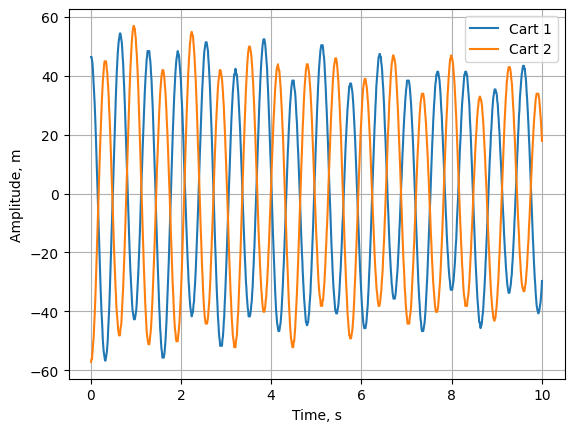

In [51]:
filename = 'https://raw.githubusercontent.com/tphlabs/data/refs/heads/main/Lab3_CO/2026.03/mode2.txt'
t, xa, xb = get_signal(filename, show=True)

initial = [100, omega_theor[0], 0, 100, omega_theor[1], 0]
# extract from a
parameters, pcov = curve_fit(harmonic2, t, xa, p0=initial)
errs = np.sqrt(np.diag(pcov))

omega1_a, omega1_a_err = parameters[1], errs[1]
omega2_a, omega2_a_err = parameters[4], errs[4]
print(f'xa Fit omega1 {omega1_a:.1f} ± {omega1_a_err:.1f} rad/s')
print(f'xa Fit omega2 {omega2_a:.1f} ± {omega2_a_err:.1f} rad/s')

# extract from b
parameters, pcov = curve_fit(harmonic2, t, xb, p0=initial)
errs = np.sqrt(np.diag(pcov))

omega1_b, omega1_b_err = parameters[1], errs[1]
omega2_b, omega2_b_err = parameters[4], errs[4]
print(f'xa Fit omega1 {omega1_b:.1f} ± {omega1_b_err:.1f} rad/s')
print(f'xa Fit omega2 {omega2_b:.1f} ± {omega2_b_err:.1f} rad/s')


xa Fit omega1 14.5 ± 0.3 rad/s
xa Fit omega2 4.4 ± 0.0 rad/s
xa Fit omega1 13.3 ± 0.2 rad/s
xa Fit omega2 4.4 ± 0.0 rad/s


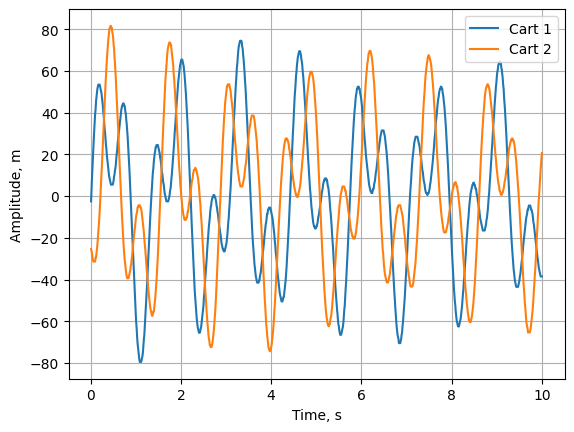

In [52]:
filename = 'https://raw.githubusercontent.com/tphlabs/data/refs/heads/main/Lab3_CO/2026.03/mode12.txt'
t, xa, xb = get_signal(filename, show=True)

initial = [100, omega_theor[0], 0, 100, omega_theor[1], 0]
# extract from a
parameters, pcov = curve_fit(harmonic2, t, xa, p0=initial)
errs = np.sqrt(np.diag(pcov))

omega1_a, omega1_a_err = parameters[1], errs[1]
omega2_a, omega2_a_err = parameters[4], errs[4]
print(f'xa Fit omega1 {omega1_a:.1f} ± {omega1_a_err:.1f} rad/s')
print(f'xa Fit omega2 {omega2_a:.1f} ± {omega2_a_err:.1f} rad/s')

# extract from b
parameters, pcov = curve_fit(harmonic2, t, xb, p0=initial)
errs = np.sqrt(np.diag(pcov))

omega1_b, omega1_b_err = parameters[1], errs[1]
omega2_b, omega2_b_err = parameters[4], errs[4]
print(f'xa Fit omega1 {omega1_b:.1f} ± {omega1_b_err:.1f} rad/s')
print(f'xa Fit omega2 {omega2_b:.1f} ± {omega2_b_err:.1f} rad/s')
